In [1]:
import numpy as np

import sys
sys.path.insert(0, '..')

from tqdm import tqdm
import carmapy

from matplotlib import pyplot as plt
import matplotlib
%load_ext autoreload
%autoreload 2

plt.rcParams.update({'font.size': 18})


In [2]:
Teff_grid = range(900, 2401, 100)
# g_grid = [31, 100, 316, 1000, 3160]
g_grid = [31]
m_grid = [0.0]
# m_grid = [-0.5, 0.0, 0.5]

numdens = np.zeros((len(Teff_grid), len(g_grid),len(m_grid), 90, 11, 80, 99))

In [21]:

Teff_grid = range(900, 2401, 100)
# g_grid = [31, 100, 316, 1000, 3160]
g_grid = [31]
m_grid = [0.0]
# m_grid = [-0.5, 0.0, 0.5]

numdens = np.zeros((len(Teff_grid), len(g_grid),len(m_grid), 90, 11, 80, 99))

for i_t in tqdm(range(len(Teff_grid))):
    for i_g in range(len(g_grid)):
        for i_m in range(len(m_grid)):

            teff = Teff_grid[i_t]
            g = g_grid[i_g]
            m = m_grid[i_m]
            
            # for _ in range(1):
            try:
                carma = carmapy.load_carma(f"../outputs/t{teff}g{g}m{m:+.1f}")
                carma.read_results()
                # if not carma.results.is_prob_converged():
                #     print("NOT CONVERGED")
                # if not numdems:
                #     numdens = np.zeros((len(Teff_grid), len(g_grid), len(m_grid), *carma.results.numden.shape)) * np.nan
                n_t = carma.results.numden.shape[3]
                if n_t < 99:
                    numdens[i_t, i_g, i_m, :, :, :, :n_t] = carma.results.numden
                else:
                    numdens[i_t, i_g, i_m, :, :, :, -99:] = carma.results.numden[:,:,:,-99:]

            except Exception as e:
                print(f"{i_t}, {i_g}, {i_m}, :{e}")
    

100%|██████████| 16/16 [08:49<00:00, 33.11s/it]


In [24]:
numdens.shape

(16, 1, 1, 90, 11, 80, 99)

/home/wcukier/ipykernel_1375629/2105470843.py:31: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  plt.colorbar(plt.cm.ScalarMappable(cmap=matplotlib.colors.ListedColormap(colors_light), norm=plt.Normalize(vmin=900, vmax=2400)), label="Teff [K]")


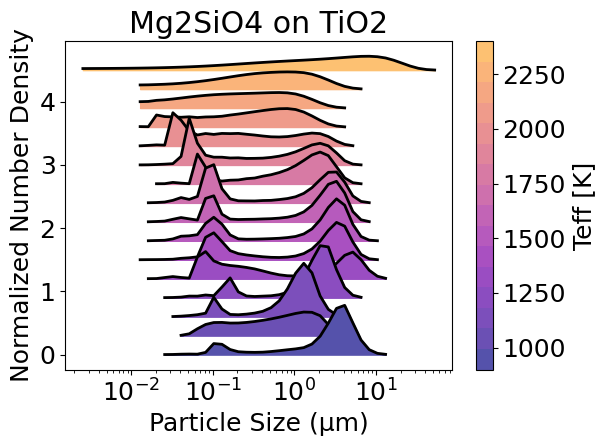

In [25]:
t_averaged = np.mean(numdens[:, :, :, :, :, :, -60:-40], axis=6)
column_sum = np.sum(t_averaged[:, :, :, :, :], axis=3)
colors = plt.cm.plasma(np.linspace(0, .8, 16))

colors_light= np.copy(colors)
colors_light[:, :3] = np.clip(colors[:, :3]*.7 + .3, 0, 1)

i_group = 3

dy = 0.3
fig, ax = plt.subplots()

for i in range(numdens.shape[0]-1, -1, -1):
    size_dist = column_sum[i, 0, 0, i_group, :]
    size_dist = size_dist/(np.sum(size_dist)* np.log(carma.results.r[1]/carma.results.r[0]))
    mask = size_dist > 0.001
    
    
    plt.plot(carma.results.r[mask], size_dist[mask]+i*dy, c='k', zorder=-2*i, lw=2)

    plt.fill_between(carma.results.r[mask], size_dist[mask]+i*dy, i*dy, color=colors_light[i], alpha=1, zorder=-2*i-1)
    
plt.xscale("log")
plt.xlabel("Particle Size (μm)")
plt.ylabel("Normalized Number Density")
plt.title(list(carma.groups.keys())[i_group])

fig.patch.set_alpha(0.0)


plt.colorbar(plt.cm.ScalarMappable(cmap=matplotlib.colors.ListedColormap(colors_light), norm=plt.Normalize(vmin=900, vmax=2400)), label="Teff [K]")

plt.tight_layout()
plt.savefig(f"ridgeline_{list(carma.groups.keys())[i_group]}.png")


/home/wcukier/ipykernel_1375629/2201061714.py:29: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  plt.colorbar(plt.cm.ScalarMappable(cmap=matplotlib.colors.ListedColormap(colors_light), norm=plt.Normalize(vmin=900, vmax=2400)), label="Teff")


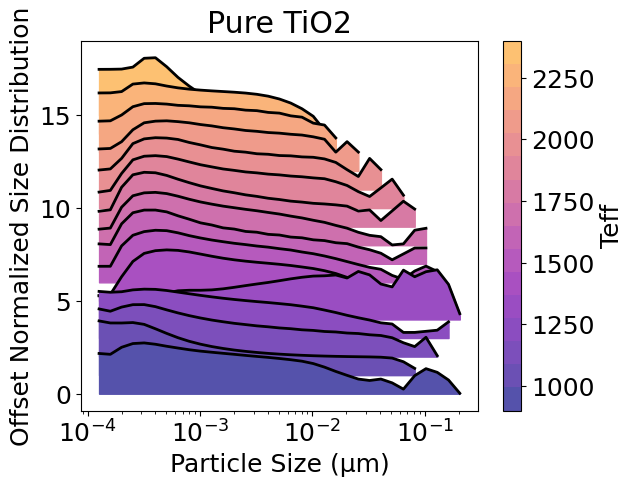

In [26]:
t_averaged = np.mean(numdens[:, :, :, :, :, :, -60:-40], axis=6)
column_sum = np.sum(t_averaged[:, :, :, :, :], axis=3)
colors = plt.cm.plasma(np.linspace(0, .8, 16))

colors_light= np.copy(colors)
colors_light[:, :3] = np.clip(colors[:, :3]*.7 + .3, 0, 1)

i_group = 0

dy = 1

for i in range(numdens.shape[0]-1, -1, -1):
    size_dist = column_sum[i, 0, 0, i_group, :]
    size_dist = size_dist/(np.sum(size_dist)* np.log(carma.results.r[1]/carma.results.r[0]))
    mask = size_dist > 0.001
    
    
    plt.plot(carma.results.r[mask], np.log10(size_dist[mask])+3+i*dy, c='k', zorder=-2*i, lw=2)

    plt.fill_between(carma.results.r[mask], np.log10(size_dist[mask])+3+i*dy, i*dy, color=colors_light[i], alpha=1, zorder=-2*i-1)
    
plt.xscale("log")
plt.xlabel("Particle Size (μm)")
plt.ylabel("Offset Normalized Size Distribution")
plt.title(list(carma.groups.keys())[i_group])



plt.colorbar(plt.cm.ScalarMappable(cmap=matplotlib.colors.ListedColormap(colors_light), norm=plt.Normalize(vmin=900, vmax=2400)), label="Teff")



/home/wcukier/ipykernel_1375629/1492078529.py:29: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  plt.colorbar(plt.cm.ScalarMappable(cmap=matplotlib.colors.ListedColormap(colors_light), norm=plt.Normalize(vmin=900, vmax=2400)), label="Teff")


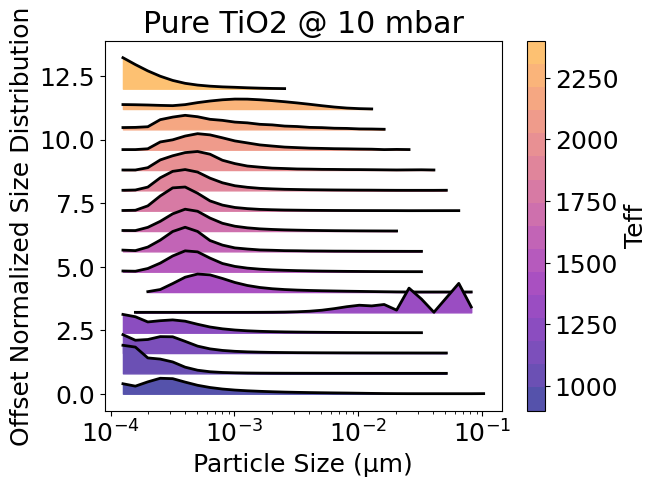

In [27]:
t_averaged = np.mean(numdens[:, :, :, :, :, :, -60:-40], axis=6)
column_sum = t_averaged[:, :, :, 57, :]
colors = plt.cm.plasma(np.linspace(0, .8, 16))

colors_light= np.copy(colors)
colors_light[:, :3] = np.clip(colors[:, :3]*.7 + .3, 0, 1)

i_group = 0

dy = 0.8

for i in range(numdens.shape[0]-1, -1, -1):
    size_dist = column_sum[i, 0, 0, i_group, :]
    size_dist = size_dist/(np.sum(size_dist)* np.log(carma.results.r[1]/carma.results.r[0]))
    mask = size_dist > 0.001
    
    
    plt.plot(carma.results.r[mask], size_dist[mask]+i*dy, c='k', zorder=-2*i, lw=2)

    plt.fill_between(carma.results.r[mask], size_dist[mask]+i*dy, i*dy, color=colors_light[i], alpha=1, zorder=-2*i-1)
    
plt.xscale("log")
plt.xlabel("Particle Size (μm)")
plt.ylabel("Offset Normalized Size Distribution")
plt.title(f"{list(carma.groups.keys())[i_group]} @ 10 mbar")



plt.colorbar(plt.cm.ScalarMappable(cmap=matplotlib.colors.ListedColormap(colors_light), norm=plt.Normalize(vmin=900, vmax=2400)), label="Teff")



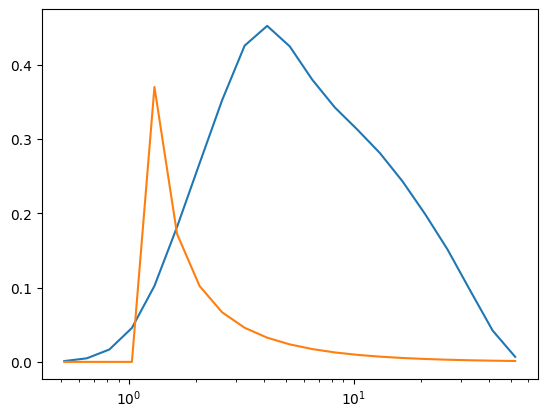

In [53]:
from scipy.stats import lognorm
from scipy.optimize import curve_fit


size_dist = column_sum[15, 0, 0, 3, :]
size_dist = size_dist/(np.sum(size_dist)* np.log(carma.results.r[1]/carma.results.r[0]))
mask = size_dist > 0.001

[s1, s2], _ = curve_fit(lambda x, s1, s2: lognorm.pdf(x,s1, s2), carma.results.r[mask], size_dist[mask])



plt.plot(carma.results.r[mask], size_dist[mask])
plt.plot(carma.results.r[mask], lognorm.pdf(carma.results.r[mask], s1, s2))
plt.xscale("log")

In [49]:

lognorm.pdf?


Signature: lognorm.pdf(x, *args, **kwds)
Docstring:
Probability density function at x of the given RV.

Parameters
----------
x : array_like
    quantiles
arg1, arg2, arg3,... : array_like
    The shape parameter(s) for the distribution (see docstring of the
    instance object for more information)
loc : array_like, optional
    location parameter (default=0)
scale : array_like, optional
    scale parameter (default=1)

Returns
-------
pdf : ndarray
    Probability density function evaluated at x
File:      /software/python-anaconda-2023.09-el8-x86_64/lib/python3.11/site-packages/scipy/stats/_distn_infrastructure.py
Type:      method


In [28]:
np.where(carma.results.P < 1e4)

(array([57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73,
        74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89]),)

In [5]:
bin_sum = np.sum(column_sum[:, 0, 0, :, :]*carma.results.r**2, axis=2)

In [6]:
[list(carma.groups.keys())[np.argmax(bin_sum[i, :])] for i in range(16)]

['Pure KCl',
 'Pure KCl',
 'Pure KCl',
 'Mg2SiO4 on TiO2',
 'Mg2SiO4 on TiO2',
 'Mg2SiO4 on TiO2',
 'Mg2SiO4 on TiO2',
 'Mg2SiO4 on TiO2',
 'Mg2SiO4 on TiO2',
 'Mg2SiO4 on TiO2',
 'Mg2SiO4 on TiO2',
 'Mg2SiO4 on TiO2',
 'Mg2SiO4 on TiO2',
 'Mg2SiO4 on TiO2',
 'Pure TiO2',
 'Pure TiO2']

/home/wcukier/ipykernel_1794506/1030227786.py:29: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  plt.colorbar(plt.cm.ScalarMappable(cmap=matplotlib.colors.ListedColormap(colors_light), norm=plt.Normalize(vmin=900, vmax=2400)), label="Teff")


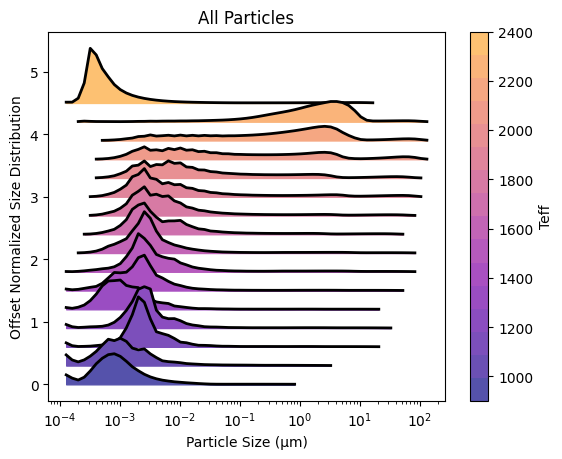

In [22]:
t_averaged = np.mean(numdens[:, :, :, :, :, :, -60:-40], axis=6)
column_sum = np.sum(t_averaged[:, :, :, :, :], axis=3)
colors = plt.cm.plasma(np.linspace(0, .8, 16))

colors_light= np.copy(colors)
colors_light[:, :3] = np.clip(colors[:, :3]*.7 + .3, 0, 1)

i_group = 3

dy = 0.3

for i in range(15, -1, -1):
    size_dist = np.sum(column_sum[i, 0, 0, :, :], axis=0)
    size_dist = size_dist/(np.sum(size_dist)* np.log(carma.results.r[1]/carma.results.r[0]))
    mask = size_dist > 0.001
    
    
    plt.plot(carma.results.r[mask], size_dist[mask]+i*dy, c='k', zorder=-2*i, lw=2)

    plt.fill_between(carma.results.r[mask], size_dist[mask]+i*dy, i*dy, color=colors_light[i], alpha=1, zorder=-2*i-1)
    
plt.xscale("log")
plt.xlabel("Particle Size (μm)")
plt.ylabel("Offset Normalized Size Distribution")
plt.title("All Particles")



plt.colorbar(plt.cm.ScalarMappable(cmap=matplotlib.colors.ListedColormap(colors_light), norm=plt.Normalize(vmin=900, vmax=2400)), label="Teff")



In [34]:
for i in range(16):
    plt.plot(np.sum())
    

(16, 1, 1, 90, 11)

In [14]:
carma.results

{}

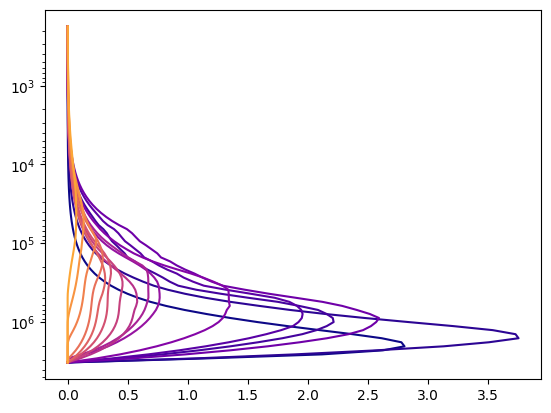

In [5]:

colors = plt.cm.plasma(np.linspace(0, .8, 16))

for i in range(16):
    plt.plot( np.transpose(np.mean(np.sum(numdens, axis=5)[:, :, :, :, -40:], axis=5)[i,0,0, :, 3]), carma.results.P, c=colors[i])
plt.yscale("log")
plt.gca().invert_yaxis()

# plt.xscale("log")

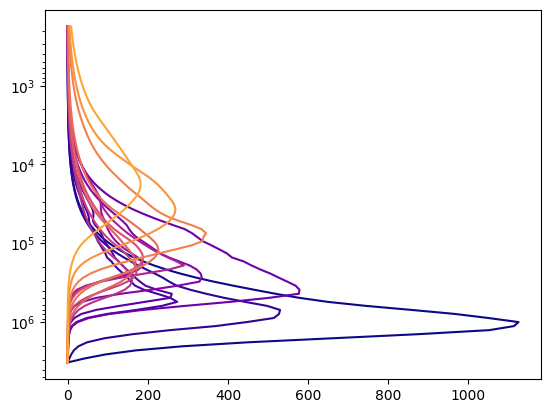

In [10]:

colors = plt.cm.plasma(np.linspace(0, .8, 16))

for i in range(16):
    plt.plot( np.transpose(np.mean(np.sum(numdens, axis=5)[:, :, :, :, -40:], axis=5)[i,0,0, :, 0]), carma.results.P, c=colors[i])
plt.yscale("log")
plt.gca().invert_yaxis()

In [18]:
os.getcwd()

'/scratch/midway3/wcukier/sample_1DCARMA/scripts'